# LaCAM runtime contrast

Two solved instances from different maps, closely matched in agent count, free space and agent density.

In [5]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

ROOT = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / "pyproject.toml").exists())
INSTANCES = [
    "lak303d-random-6-density-b3-n2291",
    "maze-128-128-10-random-21-density-b3-n2231",
]

data = (
    pd.read_csv(
        ROOT / "datasets/movingai_final.csv",
        usecols=["instance_id", "map_name", "num_agents", "lacam_seed", "lacam_solved", "lacam_runtime_seconds"],
    )
    .query("instance_id in @INSTANCES and lacam_seed == 0")
    .drop_duplicates("instance_id")
    .set_index("instance_id")
    .loc[INSTANCES]
    .reset_index()
)
assert data.lacam_solved.eq(1).all()

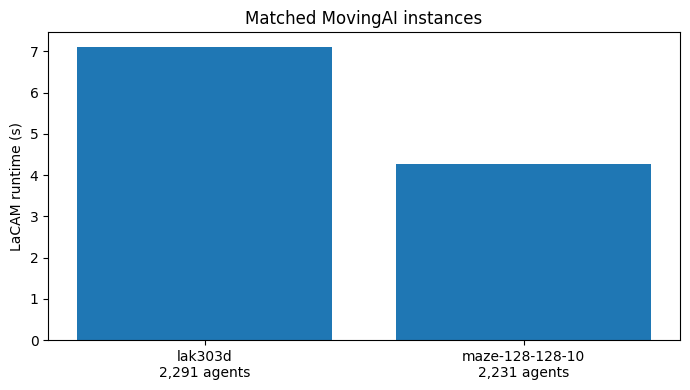

In [6]:
labels = [f"{name.removesuffix('.map')}\n{agents:,} agents" for name, agents in zip(data.map_name, data.num_agents)]
fig, axis = plt.subplots(figsize=(7, 4))
axis.bar(labels, data.lacam_runtime_seconds)
axis.set(title="Matched MovingAI instances", xlabel="", ylabel="LaCAM runtime (s)")
fig.tight_layout()